In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
import cv2

#path_cachorro = './Diretorio_imagens/Dog'
#path_gato = './Diretorio_imagens/Cat'
def remover_imagens_invalidas(path):
    for imagem in os.listdir(path):
        caminho = os.path.join(path, imagem)
        if os.path.isfile(caminho):
            try:
                image = cv2.imread(caminho)
                if image is None:
                    print(f'Imagem: {caminho} não está correta e será excluída!')
                    os.remove(caminho)
                else:
                    print(f'Imagem: {caminho} lida com sucesso!')
            except Exception as e:
                print(f'Erro ao processar a imagem {caminho}: {e}')

remover_imagens_invalidas(path_cachorro)
remover_imagens_invalidas(path_gato)

diretorio_imagens = './Diretorio_imagens'

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)

train_generator = train_datagen.flow_from_directory(
    directory = diretorio_imagens,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)
validation_generator = train_datagen.flow_from_directory(
    directory=diretorio_imagens,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

print("Treinos e testes separados!")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, MaxPooling2D

modelo = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Modelo criado e compilado!")

early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
modelo_check = ModelCheckpoint('melhor_modelo.keras', save_best_only=True)

modelo.fit(train_generator, epochs=10,validation_data=validation_generator, verbose=1, callbacks=[early_stop,modelo_check])

print("Modelo treinado!")
from tensorflow.keras.models import load_model
#modelo.save("rede_neural_tensor.h5")
modelo = load_model('rede_neural_tensor.h5')
previsao = modelo.predict(validation_generator)
print(previsao)
loss, accuracy = modelo.evaluate(validation_generator)
print(f'Perda no Teste: {loss:.4f}')
print(f'Acurácia no Teste: {accuracy:.4f}')




Imagem: ./Diretorio_imagens/Dog\0.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\1.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\100.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\1000.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10000.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10001.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10002.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10003.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10004.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10005.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10006.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10007.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10008.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10009.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\1001.jpg lida com sucesso!
Imagem: ./Diretorio_imagens/Dog\10010.jpg lida com suce

C:\Users\isaor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modelo criado e compilado!


C:\Users\isaor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 88/546 ━━━━━━━━━━━━━━━━━━━━ 4:58 651ms/step - accuracy: 0.5544 - loss: 0.7732

KeyboardInterrupt: 

array([[[0.24705882, 0.16470589, 0.04313726],
        [0.26666668, 0.19215687, 0.06666667],
        [0.27058825, 0.22745098, 0.10196079],
        ...,
        [0.02352941, 0.03137255, 0.01176471],
        [0.01176471, 0.02352941, 0.        ],
        [0.00392157, 0.01568628, 0.        ]],

       [[0.24313726, 0.16078432, 0.04705882],
        [0.26666668, 0.19215687, 0.07450981],
        [0.27450982, 0.23137255, 0.10588235],
        ...,
        [0.02352941, 0.03137255, 0.01176471],
        [0.00784314, 0.01960784, 0.        ],
        [0.00392157, 0.01568628, 0.        ]],

       [[0.24313726, 0.16078432, 0.05490196],
        [0.27058825, 0.19215687, 0.08627451],
        [0.27450982, 0.23137255, 0.11372549],
        ...,
        [0.01960784, 0.02745098, 0.00784314],
        [0.00784314, 0.01960784, 0.        ],
        [0.        , 0.01176471, 0.        ]],

       ...,

       [[0.22745098, 0.29411766, 0.09019608],
        [0.22745098, 0.29411766, 0.08235294],
        [0.22745098, 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


array([[0.9856738]], dtype=float32)

'A Imagem processada é um cachorro!'

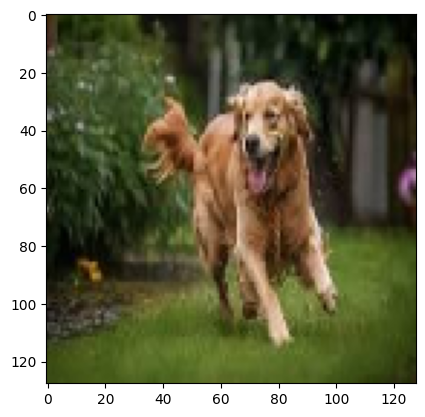

In [5]:
from tensorflow.keras.models import load_model

rede = load_model('rede_neural_tensor.h5')

from tensorflow.keras.preprocessing.image import load_img, img_to_array

imagem = load_img('download (1).jpg',target_size=(128,128))

import matplotlib.pyplot as plt

plt.imshow(imagem)

imagem_array = img_to_array(imagem)/255

display(imagem_array)
import numpy as np

imagem_ajustada = np.expand_dims(imagem_array, axis=0)

previsao = rede.predict(imagem_ajustada)
display(previsao)
if(previsao[0][0] > 0.5):
    display("A Imagem processada é um cachorro!")
else:
    display("A Imagem processada é um gato!")

